# Experiment No. 12: Convolutional Codes

## Title
**Implementation of Convolutional Coding using Python**

## Aim
To implement a convolutional encoder using Python and observe how a binary message is encoded using shift registers and modulo-2 operations.

## Theory

Convolutional coding is an **error-control coding technique** in which the encoded output depends on both the **current input bit** and some **previous input bits** stored in the encoder memory.

Unlike block coding, a convolutional encoder processes the input continuously using shift registers.

### Convolutional Encoder

The encoder used in this experiment has:

- One input bit at a time
- Two output bits for every input bit
- Two memory elements (flip-flops)

Therefore, the code rate is

$$
R = \frac{1}{2}
$$

Since two previous bits are stored, the constraint length is

$$
K = 3
$$

The encoder therefore considers

$$
[x[n],x[n-1],x[n-2]]
$$

during encoding.

### Generator Sequences

For this experiment, the generator sequences are

$$
g_1 = 111
$$

and

$$
g_2 = 101
$$

Therefore, the two encoded outputs are

$$
c_1[n]
=
x[n]\oplus x[n-1]\oplus x[n-2]
$$

and

$$
c_2[n]
=
x[n]\oplus x[n-2]
$$

where $\oplus$ represents modulo-2 addition or XOR.

For example,

$$
1\oplus1=0
$$

and

$$
1\oplus0=1
$$

### Encoder Memory and State

The two memory elements store the two previous input bits.

Since there are two memory bits, the number of possible encoder states is

$$
2^{K-1}=2^2=4
$$

The possible states are:

$$
00,\;01,\;10,\;11
$$

The state changes whenever a new input bit enters the shift register.

### Termination Bits

The message used in the laboratory experiment is

$$
m=[1\;0\;1\;1]
$$

Two zeros are added at the end:

$$
[1\;0\;1\;1\;0\;0]
$$

These zeros flush the remaining information from the shift registers and return the encoder toward the zero state.

### Trellis and Decoding

A convolutional encoder can also be represented using a **state diagram** or **trellis**.

The trellis shows how the encoder changes from one state to another for each input bit. At the receiver, algorithms such as the **Viterbi algorithm** can use this trellis to find the most likely transmitted message when transmission errors occur.

In this experiment, we focus mainly on the **encoding process**.

## Convolutional Coding Flow

**Binary Message → Shift Registers → XOR Operations → Encoded Output**

## Algorithm

1. Define the binary input message.
2. Add two termination zeros.
3. Initialize the two memory elements to zero.
4. Read one input bit at a time.
5. Generate the first output using:

$$
c_1=x\oplus D_1\oplus D_2
$$

6. Generate the second output using:

$$
c_2=x\oplus D_2
$$

7. Shift the register contents.
8. Repeat the process for all input bits.
9. Combine the output pairs to form the final encoded sequence.
10. Plot the input and encoded signals.

## Output

The program displays:

1. Original message
2. Terminated input sequence
3. Encoder state for each input
4. Encoded output pairs
5. Serial convolutionally encoded sequence
6. Input and encoded waveforms

## Result and Discussion

The message

$$
[1\;0\;1\;1]
$$

was encoded using a rate-$1/2$ convolutional encoder with generator sequences

$$
g_1=111,\qquad g_2=101
$$

After adding two termination zeros, the encoder input became

$$
[1\;0\;1\;1\;0\;0]
$$

The generated output pairs were

$$
11,\;10,\;00,\;01,\;01,\;11
$$

Therefore, the final serial encoded sequence was

$$
111000010111
$$

The experiment demonstrates that convolutional coding introduces redundancy by generating output bits based on both the present input and previous input bits.

## Conclusion

Convolutional coding was successfully implemented using Python. The experiment demonstrated the operation of shift registers, encoder memory, generator sequences, modulo-2 addition, and generation of a rate-$1/2$ convolutionally encoded sequence.

Original Message : [1 0 1 1]
Encoder Input    : [1 0 1 1 0 0]
Generator 1      : 111
Generator 2      : 101

Input   State   Output
----------------------
  1      00      11
  0      10      10
  1      01      00
  1      10      01
  0      11      01
  0      01      11

Output Pairs : 11 10 00 01 01 11
Encoded Bits : 111000010111


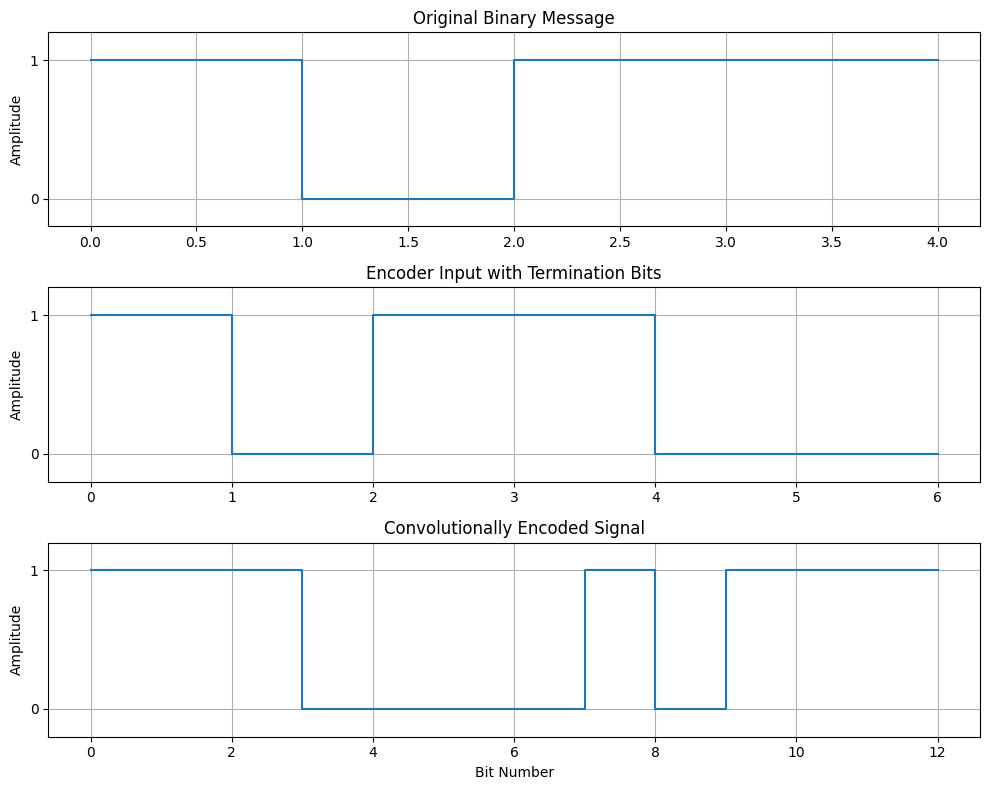

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Original message from the lab experiment
message = np.array([1, 0, 1, 1])

# Two termination zeros for two memory elements
input_bits = np.append(message, [0, 0])

# Initial shift-register contents
d1 = 0
d2 = 0

c1 = []
c2 = []
states = []
encoded_pairs = []

# Convolutional encoding
for bit in input_bits:

    # Store current encoder state
    states.append(f"{d1}{d2}")

    # Generator g1 = 111
    out1 = bit ^ d1 ^ d2

    # Generator g2 = 101
    out2 = bit ^ d2

    c1.append(out1)
    c2.append(out2)

    encoded_pairs.append([out1, out2])

    # Shift register
    d2 = d1
    d1 = bit

c1 = np.array(c1)
c2 = np.array(c2)
encoded_pairs = np.array(encoded_pairs)

# Convert output pairs into serial encoded sequence
encoded_bits = encoded_pairs.flatten()

# Display results
print("Original Message :", message)
print("Encoder Input    :", input_bits)
print("Generator 1      : 111")
print("Generator 2      : 101")
print()

print("Input   State   Output")
print("----------------------")

for i in range(len(input_bits)):
    print(
        f"  {input_bits[i]}      "
        f"{states[i]}      "
        f"{encoded_pairs[i][0]}"
        f"{encoded_pairs[i][1]}"
    )

print()
print("Output Pairs :",
      " ".join("".join(map(str, pair))
               for pair in encoded_pairs))

print("Encoded Bits :",
      "".join(map(str, encoded_bits)))


# -----------------------
# Plotting
# -----------------------

plt.figure(figsize=(10, 8))

# Original message
plt.subplot(3, 1, 1)
plt.step(
    np.arange(len(message) + 1),
    np.append(message, message[-1]),
    where="post"
)
plt.title("Original Binary Message")
plt.ylabel("Amplitude")
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.grid()

# Encoder input with termination bits
plt.subplot(3, 1, 2)
plt.step(
    np.arange(len(input_bits) + 1),
    np.append(input_bits, input_bits[-1]),
    where="post"
)
plt.title("Encoder Input with Termination Bits")
plt.ylabel("Amplitude")
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.grid()

# Final convolutionally encoded sequence
plt.subplot(3, 1, 3)
plt.step(
    np.arange(len(encoded_bits) + 1),
    np.append(encoded_bits, encoded_bits[-1]),
    where="post"
)
plt.title("Convolutionally Encoded Signal")
plt.xlabel("Bit Number")
plt.ylabel("Amplitude")
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.grid()

plt.tight_layout()
plt.show()